In [1]:
!pip install kagglehub pandas scikit-learn matplotlib seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
rng = 42
test_size = 0.25
dev_mode = True
dev_dpi = 100
prod_dpi = 1000
optimize = {
    "Logistic Regression": True,
    "Decision Tree": True,
    "Bagging": True
}

In [4]:
# models[my_model]['model'] is post fitting
models = {}

# Rain in Australia

## Motivation and Question

### Real-world motivation

Rainfall is one of the most difficult weather events. According to ABC News Australia (Australian Broadcasting Corporation), citing data from the Australia Bureau of Meteorology, Australia's official national weather agency, rainfall is in fact more difficult to forecast than temperature because it has much greater local and temporal variability. Despite major advances in the forecasting system, it remains a challenging tasks in many parts of the world. 

Improving rainfall prediction can helper farmers plan irrigation and harvesting, as well as enable emergency services to respond more effectively to severe weather conditions. It could also help individuals and businesses make better decisions about outdoor activities and operations. 

### Prediction Question

Can we accurately predict whether it will rain tomorrow in Australia using today’s weather metrics?

## Target Variable and Class Labels

### Target Variable 
RainTomorrow

### Class labels 
* Yes - It will rain tomorrow
* No - It will not rain tomorrow

This is a binary classification problem

## Data Source, Observations, and Main Features

### Dataset source
* Kaggle: Rain in Australia (Weather Dataset Rattle Package)

### Dataset overview

* 145,000 daily weather observations
* 23 variables
* Weather records collected from multiple Australian locations over about 10 years

### Main Features

* Date & Location
    * Date
    * Location
* Temperature
    * MinTemp
    * MaxTemp
    * Temp9am
    * Temp3pm
* Rainfall
    * Rainfall
    * RainToday
* Wind
    * WindGustSpeed
    * WindGustDir
    * WindSpeed9am
    * WindSpeed3pm
    * WindDir9am
    * WindDir3pm
* Atmospheric Conditions
    * Humidity9am
    * Humidity3pm
    * Pressure9am
    * Pressure3pm
    * Cloud9am
    * Cloud3pm
    * Sunshine
    * Evaporation
* Target Variable
    * RainTomorrow (Yes / No)

### Import Dataset

In [5]:
import kagglehub
from pathlib import Path

# Download latest version
handle = "jsphyg/weather-dataset-rattle-package"
path = "weatherAUS.csv"
if not Path(path).exists():
    print("Downloading from Kaggle")
    path = kagglehub.dataset_download(
        "jsphyg/weather-dataset-rattle-package",
        "weatherAUS.csv",
        output_dir="."
    )

print("Path to dataset files:", path)

Path to dataset files: weatherAUS.csv


/Users/ben/Docs/College/Waseda/Intermediate Data Science/ids_pbl2_rain-in-australia/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv(path)

## Cleaning and Preprocessing

* Handling null values should happend before enrichment.
    * Except some enrichment should happend before getting rid of null values. For example, consecutive rain days
* Enrichment should happen before EDA
* EDA should happen before preprocessing
* Some amount of EDA should handle any imputed (estimated and added in) null values, if we're using any
    * E.g. Box plot with and without imputed values

* Handle categorical values ([ordinal][sklearn.preprocessing.OrdinalEncoder], [one-hot][sklearn.preprocessing.OneHotEncoder], [target][sklearn.preprocessing.TargetEncoder])
* [Standardize scalers][sklearn.preprocessing.StandardScaler]?
* Handle null values
    * Delete: simply drop any rows/columns with missing values, especially if they are few and missingness is random
    * Impute: replace with estimated values
        * with mean, median, or mode
        * using forward/backward fill - duplicating in the previous/next seen value...
    * Interpolate from nearby values...

[sklearn.preprocessing.OrdinalEncoder]: https://scikit-learn.org/1.9/modules/generated/sklearn.preprocessing.OrdinalEncoder.html#sklearn.preprocessing.OrdinalEncoder
[sklearn.preprocessing.OneHotEncoder]: https://scikit-learn.org/1.9/modules/generated/sklearn.preprocessing.OneHotEncoder.html#sklearn.preprocessing.OneHotEncoder
[sklearn.preprocessing.TargetEncoder]: https://scikit-learn.org/1.9/modules/generated/sklearn.preprocessing.TargetEncoder.html#sklearn.preprocessing.TargetEncoder
[sklearn.preprocessing.StandardScaler]: https://scikit-learn.org/1.9/modules/generated/sklearn.preprocessing.StandardScaler.html

According to the [Australian Government's Bureau of Meterology](https://www.bom.gov.au/climate/dwo/IDCJDW0000.shtml), "From time to time, observations will not be available, for a variety of reasons. Sometimes when the daily maximum and minimum temperatures, rainfall or evaporation are missing, the next value given has been accumulated over several days rather than the normal one day. It is very difficult for an automatic system to detect this reliably, so caution is advised."

In [7]:
print(f"Number of columns with a significant amount of missing data: {((df.isnull().sum() / df.shape[0]) > 0.05).sum()} / {df.shape[1]} = {((df.isnull().sum() / df.shape[0]) > 0.05).sum() / df.shape[1]}")
print(f"Number of rows with at least one missing feature: {(df.isnull().sum(axis=1) > 0).sum()} / {df.shape[0]} = {(df.isnull().sum(axis=1) > 0).sum() / df.shape[0]}")
print(f"Number of rows with more than one missing feature: {(df.isnull().sum(axis=1) > 2).sum()} / {df.shape[0]} = {(df.isnull().sum(axis=1) > 2).sum() / df.shape[0]}")

Number of columns with a significant amount of missing data: 9 / 23 = 0.391304347826087
Number of rows with at least one missing feature: 89040 / 145460 = 0.6121270452358036
Number of rows with more than one missing feature: 59785 / 145460 = 0.41100646225766535


In [8]:
from sklearn.impute import SimpleImputer
# 1. Remove rows with missing target variable
df = df[df["RainTomorrow"].notna()].copy()

In [9]:
# Make sure Date is datetime
df["Date"] = pd.to_datetime(df["Date"])

# Create season/month
df["Month"] = df["Date"].dt.month

# Separate columns
target = "RainTomorrow"
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
categorical_cols.remove(target)
numerical_cols = df.select_dtypes(include=["number"]).columns.tolist()

In [10]:
# Numerical: fill by Location + Month median first
for col in numerical_cols:
    df[col] = df.groupby(["Location", "Month"])[col].transform(
        lambda x: x.fillna(x.median())
    )
    # fallback if some Location+Month group is still all missing
    df[col] = df[col].fillna(df[col].median())

# Categorical: fill by Location mode first
for col in categorical_cols:
    df[col] = df.groupby("Location")[col].transform(
        lambda x: x.fillna(x.mode()[0] if not x.mode().empty else np.nan)
    )
    # fallback
    df[col] = df[col].fillna(df[col].mode()[0])

/Users/ben/Docs/College/Waseda/Intermediate Data Science/ids_pbl2_rain-in-australia/.venv/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ben/Docs/College/Waseda/Intermediate Data Science/ids_pbl2_rain-in-australia/.venv/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ben/Docs/College/Waseda/Intermediate Data Science/ids_pbl2_rain-in-australia/.venv/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Users/ben/Docs/College/Waseda/Intermediate Data Science/ids_pbl2_rain-in-australia/.venv/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


Instead of using a single global median for all missing numerical values, we used grouped imputation based on location and month. This is more appropriate for weather data because temperature, rainfall, humidity, and pressure vary strongly across regions and seasons. For categorical variables, missing values were filled using the most frequent value within each location, with a global mode as a fallback. Rows with missing RainTomorrow were removed because the target label should not be artificially created.

In [ ]:
# Encode target
# TODO: The classifier might not need this
df[target] = df[target].map({"No": 0, "Yes": 1})
print("Missing values remaining:", df.isnull().sum().sum())

Missing values remaining: 0


### Enrich Dataset
- TempRange — MaxTemp minus MinTemp
- MonsoonSeason — location-aware wet/monsoon flag (Yes/No)
- WindSpeedDiff — WindSpeed3pm minus WindSpeed9am (signed)
- HumidityDiff — Humidity3pm minus Humidity9am (signed)
- TempDiff9am3pm — Temp3pm minus Temp9am (signed)
- PressureDiff — Pressure3pm minus Pressure9am (signed)
- DewPoint9am — dew point from 9am temp and humidity
- Season — Southern Hemisphere season from date
- DaysSinceRain — days since last rain per location
- ConsecutiveRainDays — consecutive rainy days before current day
- LaNina — monthly La Niña flag from NOAA NINO3.4 anomaly

In [12]:
from enrich_weather import enrich
df = enrich(df)

In [ ]:
print("Number of columns with a significant amount of missing data", ((df.isnull().sum() / df.shape[0]) > 0.05).sum())
print(f"Number of rows with no missing features: {(df.isnull().sum(axis=1) == 0).sum()} / {df.shape[0]} = {(df.isnull().sum(axis=1) == 0).sum() / df.shape[0]}")
df.isna().sum()

Number of columns with a significant amount of missing data 0
Number of rows with no missing features: 141549 / 142193 = 0.9954709444206115


There are a few rows still with missing data. These are from `DaysSinceRain` (except 1 from `DewPoint9am` for... some reason) which is actually normal behavior for that computed feature: We rely on having a first instance of rain to compute subsequent days. This means that any non-rainy days before that (i.e. all days before the first rainy day) are indeterminent which we choose to set to NA.

Since the remaining missing data is so negligible (less than 1%), we simply drop them.

In [ ]:
df = df.dropna()
print(f"Number of rows with no missing features: {(df.isnull().sum(axis=1) == 0).sum()} / {df.shape[0]} = {(df.isnull().sum(axis=1) == 0).sum() / df.shape[0]}")

## Exploratory Data Analysis
e.g. Description: columns, data-types, null values, counts, mean, standard deviation, box plot: min, 25%, 50%, 75% max; Distribution: target, target vs. key features, correlation matrix; target class balance

## Train-Test Split

### Preprocessing

[This wind modelling project](https://www.codespeedy.com/wind-direction-and-speed-prediction-using-machine-learning-in-python/) just uses degrees for the wind direction and get... passable results. I also can't think of a way to properly encode that mod activity of compass directions. One could just do it like this and another way (probably One-Hot) and see if you get a difference.

In [15]:
DIRECTIONS = ['N', 'NNE', 'NE', 'ENE',
              'E', 'ESE', 'SE', 'SSE', 
              'S', 'SSW', 'SW', 'WSW',
              'W', 'WNW', 'NW', 'NNW']
DEGREES = np.arange(0, 360, 360/len(DIRECTIONS))
DIRECTIONS_DEGREES = dict(zip(DIRECTIONS, DEGREES))
def direc_to_deg(direc: pd.DataFrame) -> float:
    return direc.map(str.upper).map(DIRECTIONS_DEGREES.get)

# Extra 1 and 0 entries for redundancy on multiple runnings
YES_NO_BINARY = { 'Yes': 1, 'No': 0,
                  1: 1,     0: 0 }
def yes_no_binary(b: pd.DataFrame) -> float:
    return b.map(YES_NO_BINARY.get)

In [16]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler

preprocessing = make_column_transformer(
    (FunctionTransformer(direc_to_deg, feature_names_out="one-to-one"), ["WindGustDir", "WindDir9am", "WindDir3pm"]),
    (OneHotEncoder(), ["Location", "Season"]),
    (FunctionTransformer(yes_no_binary, feature_names_out="one-to-one"), ["RainToday", "MonsoonSeason", "LaNina"]),
    (StandardScaler(), ["MinTemp", "MaxTemp", "Rainfall", "Evaporation", "Sunshine", "WindGustSpeed", "WindSpeed9am", "WindSpeed3pm", "Humidity9am", "Humidity3pm", "Pressure9am", "Pressure3pm", "Cloud9am", "Cloud3pm", "Temp9am", "Temp3pm", "TempRange", "WindSpeedDiff", "HumidityDiff", "TempDiff9am3pm", "PressureDiff", "DewPoint9am", "DaysSinceRain", "ConsecutiveRainDays"])
)

In [ ]:
# Things get funky when the traget needs preprocessing. Easy solution is to just pre-transform the target
# TODO: this is handled in cleaning above?
df['RainTomorrow'] = FunctionTransformer(yes_no_binary, feature_names_out="one-to-one").fit_transform(df['RainTomorrow'])

### Target-Feature Split, Train-Test Split  

In [18]:
target = 'RainTomorrow'

In [19]:
y = df[target]
X = df.drop(target, axis=1)

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=rng)

## Modelling

### Simple Model

The only "classifcation model" simplier than logistic regression or a decision tree would be simple descriptions of the model: mode and proportion. Simply use either (i) always guess mode or (ii) randomly guess weighted by proportion.

In [21]:
y_mode = y_train.mode().iloc[0]
y_prop = y_train.mean()

#### Evaluation

In [22]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("Mode:", y_mode)
pred = np.repeat(y_mode, len(y_train))
models["mode"] = { "model": y_mode, "train_predictions": pred, "test_predictions": np.repeat(y_mode, len(y_test))}
print()
print("Confusion Matrix:\n", confusion_matrix(y_train, pred))
print()
print("Classification Report:\n", classification_report(y_train, pred, zero_division=0))
print()
print("Accuracy:", accuracy_score(y_train, pred))

Mode: 0

Confusion Matrix:
 [[82229     0]
 [23932     0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.77      1.00      0.87     82229
           1       0.00      0.00      0.00     23932

    accuracy                           0.77    106161
   macro avg       0.39      0.50      0.44    106161
weighted avg       0.60      0.77      0.68    106161


Accuracy: 0.7745688152899841


In [23]:
print("Proportion Correct:", y_prop)
pred = np.random.default_rng(rng).choice([1, 0], p=[y_prop, 1-y_prop], size=len(y_train))
models["proportion_correct"] = { "model": y_prop, 
                   "train_predictions": pred, 
                   "test_predictions": np.random.default_rng(rng).choice([1, 0], p=[y_prop, 1-y_prop], size=len(y_test))}
print()
print("Confusion Matrix:\n", confusion_matrix(y_train, pred))
print()
print("Classification Report:\n", classification_report(y_train, pred, zero_division=0))
print()
print("Accuracy:", accuracy_score(y_train, pred))


Proportion Correct: 0.2254311847100159

Confusion Matrix:
 [[63826 18403]
 [18533  5399]]

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.78      0.78     82229
           1       0.23      0.23      0.23     23932

    accuracy                           0.65    106161
   macro avg       0.50      0.50      0.50    106161
weighted avg       0.65      0.65      0.65    106161


Accuracy: 0.6520756209907593


### Interpretable Model
Logistic regression or decision tree

#### Logistic Regression Model

In [24]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone

lr = make_pipeline(clone(preprocessing), LogisticRegression(random_state=rng, max_iter=10000))
lr.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('functiontransformer-1', ...), ('onehotencoder', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


##### Description

In [25]:
lr_model = lr['logisticregression']
models["logisticregression"] = {"pipeline": lr, "model": lr_model}
lr_coef = lr_model.coef_
fitted_features = lr['columntransformer'].get_feature_names_out()
lr_coef = np.append(lr_coef, lr_model.intercept_)

fitted_features = list(map(lambda n, s: s[n+2:], np.vectorize(lambda s: s.find('__'))(fitted_features), fitted_features))
fitted_features.append('Intercept')

In [54]:
def feature_coefs(ax, coefs: list[float], feature_labels: list[str], set_ylabel=False, label=None):
    res = ax.plot(range(len(coefs)), coefs)
    ax.plot(range(len(coefs)), [0]*len(coefs), '--', label=label)
    ax.set_xticks(range(len(coefs)), feature_labels, rotation=60, horizontalalignment='right')
    if set_ylabel:
        ax.set_ylabel('Coefficients')
    ax.xaxis.grid()
    return res

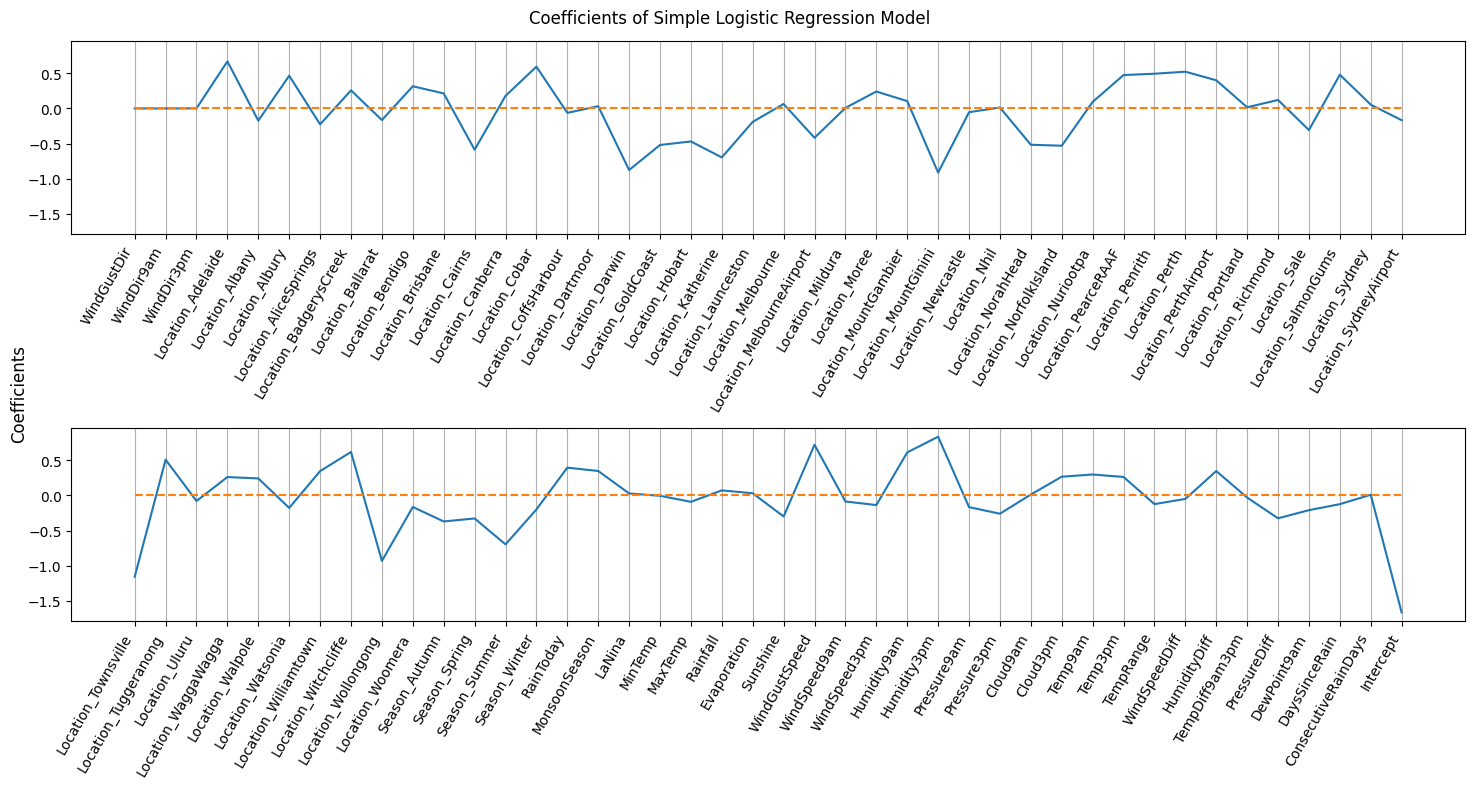

In [53]:
f, axs = plt.subplots(nrows=2, sharey=True, figsize=(15,8), dpi=dev_dpi if dev_mode else prod_dpi)

n_feat = len(fitted_features)
half = n_feat // 2

feature_coefs(axs[0], lr_coef[:half], fitted_features[:half])
feature_coefs(axs[1], lr_coef[half:], fitted_features[half:])

f.suptitle("Coefficients of Simple Logistic Regression Model")
f.supylabel('Coefficients')
f.tight_layout()
plt.show();

##### Optimizing Parameters

In [28]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegressionCV

if optimize["Logistic Regression"]:
    cs = np.logspace(-6, 1, 1000)
    lrcv = make_pipeline(clone(preprocessing), LogisticRegressionCV(Cs=cs, max_iter=10000, random_state=rng))
    lrcv.fit(X_train, y_train)

In [29]:
if optimize["Logistic Regression"]:
    lrcv_model = lrcv['logisticregressioncv']
    models['logisticregressioncv'] = {"pipeline": lrcv, "model": lrcv_model, "cv_method": lrcv_model}
    coefs_ = lrcv_model.coefs_paths_[1]

Logistic regression path of C (inverse of regression strength) vs. coefficients

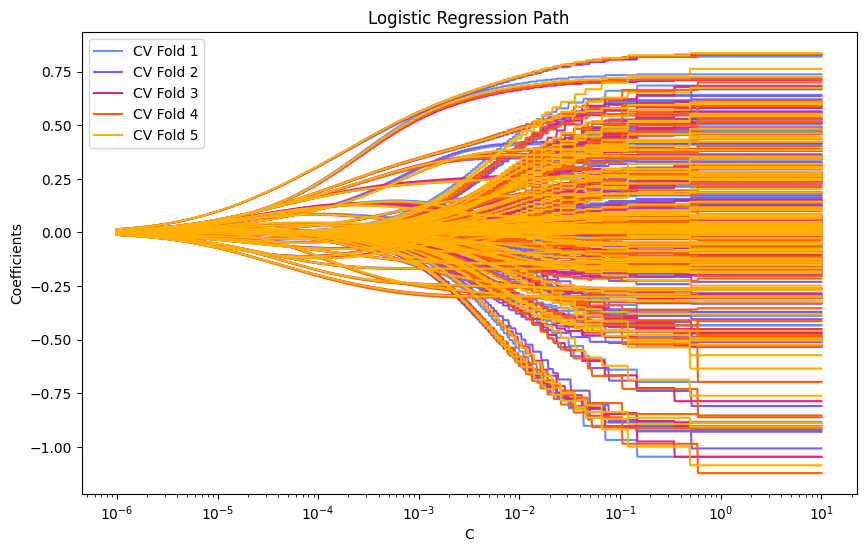

In [30]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

if optimize["Logistic Regression"]:
    # Colorblind-friendly palette (IBM Color Blind Safe palette)
    colors = ["#648FFF", "#785EF0", "#DC267F", "#FE6100", "#FFB000"]

    plt.figure(figsize=(10, 6), dpi=dev_dpi if dev_mode else prod_dpi)
    for j in range(coefs_.shape[0]):
        for i in range(coefs_.shape[2]-1):
            plt.plot(cs, coefs_[j, :, i], color=colors[j])

    ymin, ymax = plt.ylim()
    plt.xscale('log')
    plt.xlabel("C")
    plt.ylabel("Coefficients")
    plt.title("Logistic Regression Path")
    plt.legend(handles=[mlines.Line2D([], [], color=colors[i], label=f'CV Fold {i+1}') for i in range(len(colors))])
    plt.axis("tight")
    plt.show()

That's unintelligible (it's literally $5 \times 60 = 300$ plots). But from the few strands we can pick out, the folds seem to be generally aligned. At least enough so that we can just look at one of them and call it a day

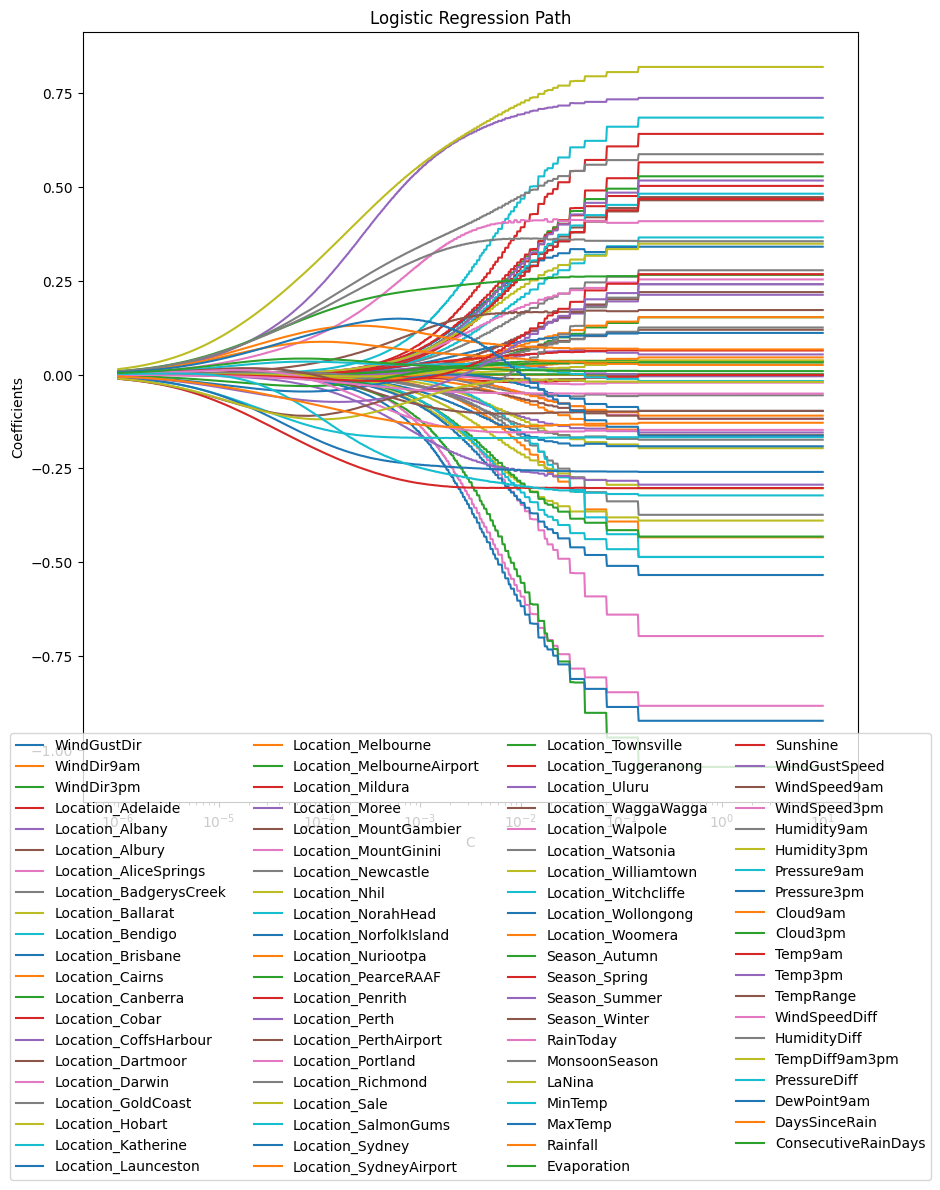

In [31]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

if optimize["Logistic Regression"]:
    # Colorblind-friendly palette (IBM Color Blind Safe palette)
    plt.figure(figsize=(10, 10), dpi=dev_dpi if dev_mode else prod_dpi)
    for i in range(coefs_.shape[2]-1):
        plt.plot(cs, coefs_[0, :, i], label=fitted_features[i])

    ymin, ymax = plt.ylim()
    plt.xscale('log')
    plt.xlabel("C")
    plt.ylabel("Coefficients")
    plt.title("Logistic Regression Path")
    plt.legend(ncol=4, loc='lower center', bbox_to_anchor=(0.5, -0.5))
    plt.axis("tight")
    plt.show()

C (inverse of regularization strength) vs. Accuracy

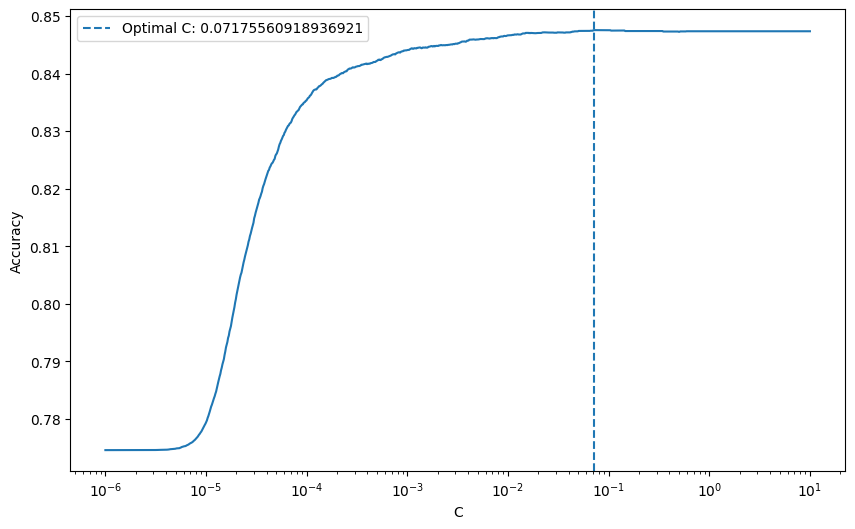

In [32]:
if optimize["Logistic Regression"]:
    f, ax = plt.subplots(figsize=(10, 6), dpi=dev_dpi if dev_mode else prod_dpi)

    mean_scores = lrcv_model.scores_[1].mean(axis=0)
    ax.plot(cs, mean_scores)
    ax.axvline(lrcv_model.C_[0], ls='--', label=f"Optimal C: {lrcv_model.C_[0]}")
    ax.set_xscale('log')
    ax.set_ylabel('Accuracy')
    ax.set_xlabel('C')
    plt.legend()
    plt.plot();

Visualize optimal coefficients

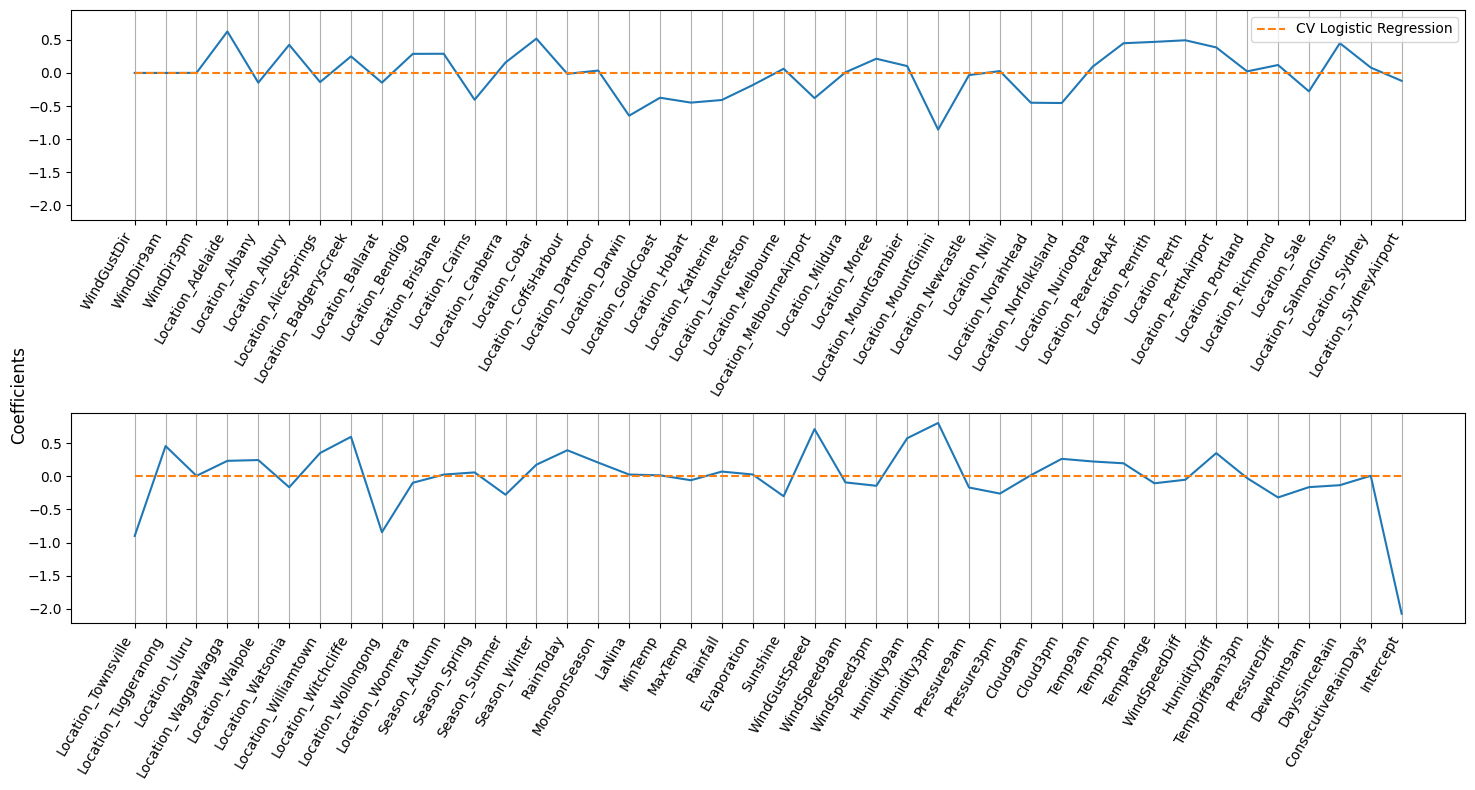

In [55]:
if optimize["Logistic Regression"]:
    lrcv_coef = lrcv_model.coef_[0]
    fitted_features = lr['columntransformer'].get_feature_names_out()
    fitted_features = list(map(lambda n, s: s[n+2:], np.vectorize(lambda s: s.find('__'))(fitted_features), fitted_features))
    lrcv_coef = np.append(lrcv_coef, lrcv_model.intercept_)
    fitted_features.append('Intercept')

    f, axs = plt.subplots(nrows=2, figsize=(15,8), dpi=dev_dpi if dev_mode else prod_dpi)

    n_feat = len(fitted_features)
    half = n_feat // 2

    feature_coefs(axs[0], lrcv_coef[:half], fitted_features[:half], label="CV Logistic Regression")
    feature_coefs(axs[1], lrcv_coef[half:], fitted_features[half:])
    # TODO: sharey?
    axs[0].sharey(axs[1])
    axs[0].legend()
    f.supylabel('Coefficients')
    f.tight_layout()
    plt.show();

Visualize optimal coefficients against default (they're basically the same)

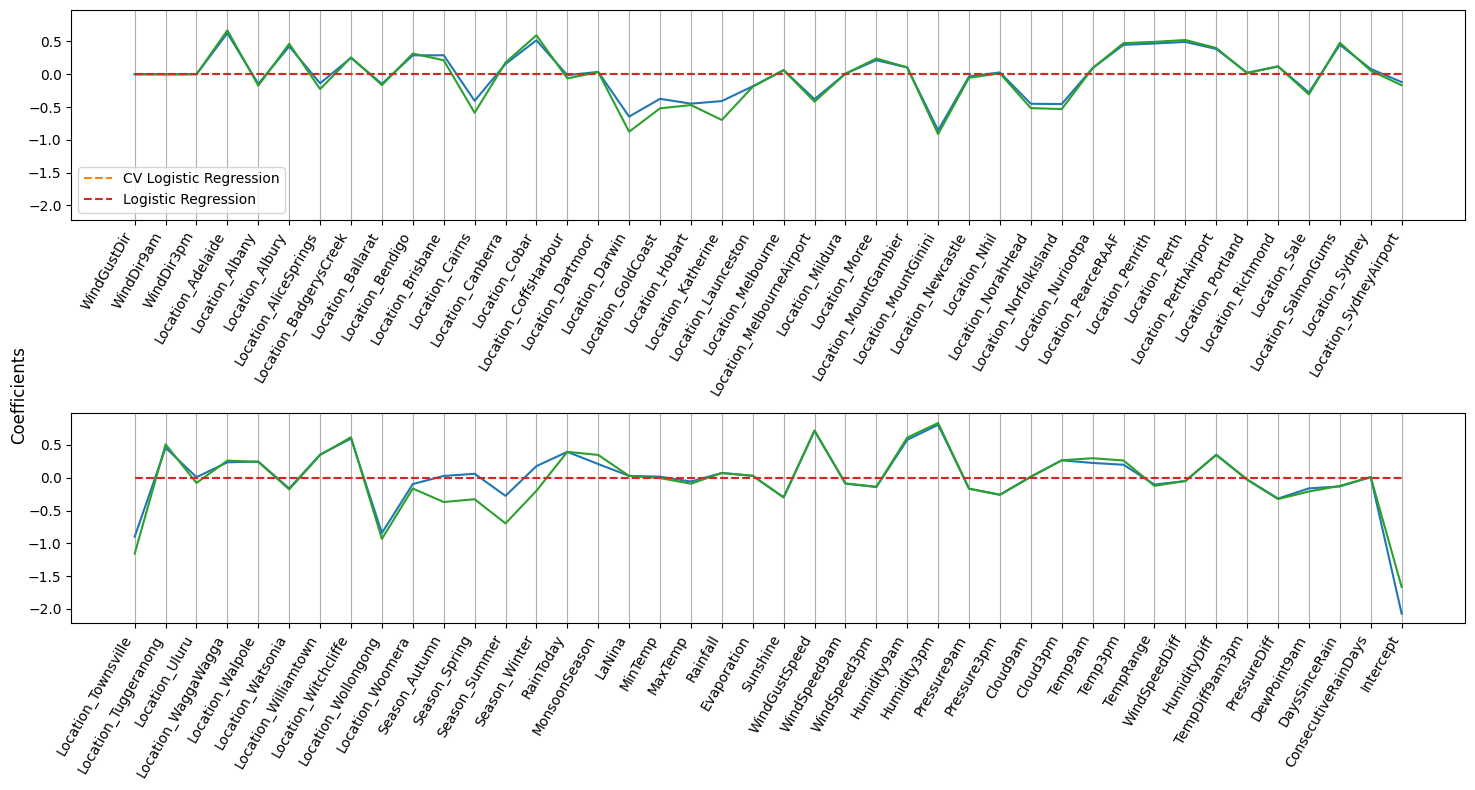

In [56]:
if optimize["Logistic Regression"]:
    lrcv_coef = lrcv_model.coef_[0]
    fitted_features = lr['columntransformer'].get_feature_names_out()
    fitted_features = list(map(lambda n, s: s[n+2:], np.vectorize(lambda s: s.find('__'))(fitted_features), fitted_features))
    lrcv_coef = np.append(lrcv_coef, lrcv_model.intercept_)
    fitted_features.append('Intercept')

    f, axs = plt.subplots(nrows=2, figsize=(15,8), dpi=dev_dpi if dev_mode else prod_dpi)

    n_feat = len(fitted_features)
    half = n_feat // 2

    feature_coefs(axs[0], lrcv_coef[:half], fitted_features[:half], label="CV Logistic Regression")
    feature_coefs(axs[1], lrcv_coef[half:], fitted_features[half:])
    feature_coefs(axs[0], lr_coef[:half], fitted_features[:half], label="Logistic Regression")
    feature_coefs(axs[1], lr_coef[half:], fitted_features[half:])
    # TODO: sharey?
    axs[0].sharey(axs[1])
    axs[0].xaxis.grid()
    axs[1].xaxis.grid()
    axs[0].legend()
    f.supylabel('Coefficients')
    f.tight_layout()
    plt.show();

#### Decision Tree Classifier

In [35]:
from sklearn.tree import DecisionTreeClassifier

tree = make_pipeline(clone(preprocessing), DecisionTreeClassifier(max_depth=3, random_state=rng))
tree.fit(X_train, y_train)

,steps,"[('columntransformer', ...), ('decisiontreeclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('functiontransformer-1', ...), ('onehotencoder', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [36]:
models["decisiontreeclassifier"] = {"pipeline": tree, "model": tree['decisiontreeclassifier']}

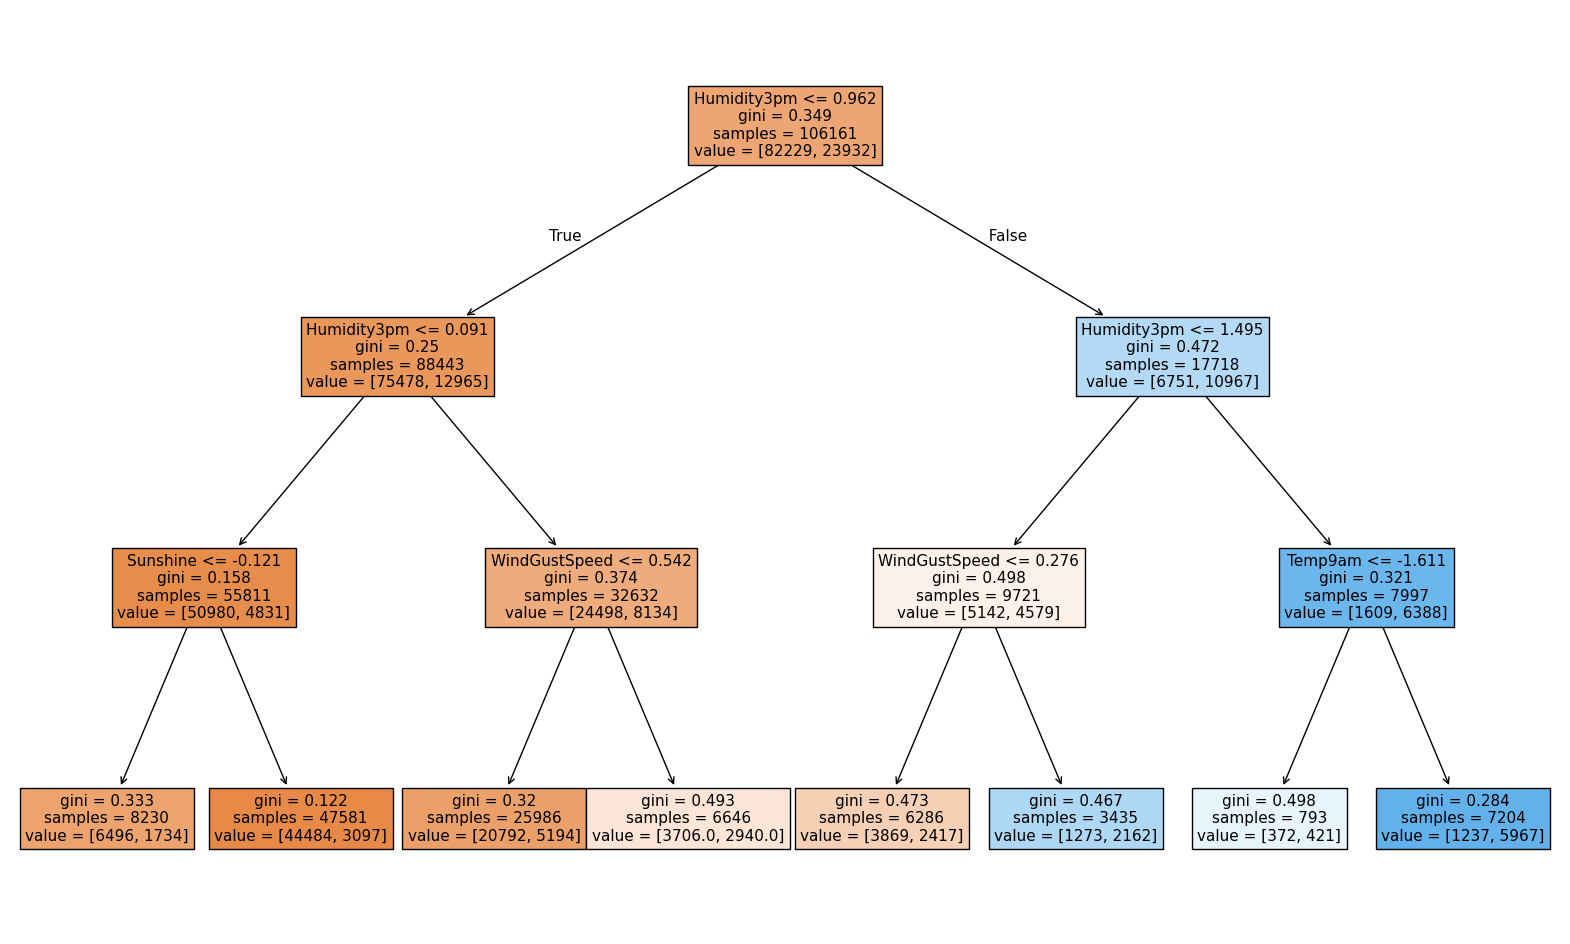

In [37]:
from sklearn.tree import plot_tree as sklearn_plot_tree

def plot_tree(tree):
    f, ax = plt.subplots(figsize=(20, 12), dpi=dev_dpi if dev_mode else prod_dpi)
    sklearn_plot_tree(tree, feature_names=fitted_features, fontsize=11, filled=True, ax=ax);

plot_tree(tree['decisiontreeclassifier'])

##### Optimized Parameters
* `max_depth`
* `min_samples_split`
* `min_samples_leaf`

In [38]:
from sklearn.model_selection import GridSearchCV
if optimize["Decision Tree"]:
    param_grid = {
        'max_depth': range(1, 11),
        'min_samples_split': range(2, 21),
        'min_samples_leaf': range(1, 21),
    }
    treecv = make_pipeline(clone(preprocessing), GridSearchCV(DecisionTreeClassifier(random_state=rng), param_grid, verbose=0))
    treecv.fit(X_train, y_train)

In [39]:
if optimize["Decision Tree"]:
    treecv_model = treecv['gridsearchcv']
    models['decisiontreecv'] = {"pipeline": treecv, "model": treecv_model.best_estimator_, "cv_method": treecv_model}
    best_tree = treecv_model.best_estimator_
    score_columns = ['split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score']
    columns = ['param_max_depth', 'param_min_samples_split', 'param_min_samples_leaf']
    columns.extend(score_columns)

    scores = pd.DataFrame(treecv_model.cv_results_)[columns]

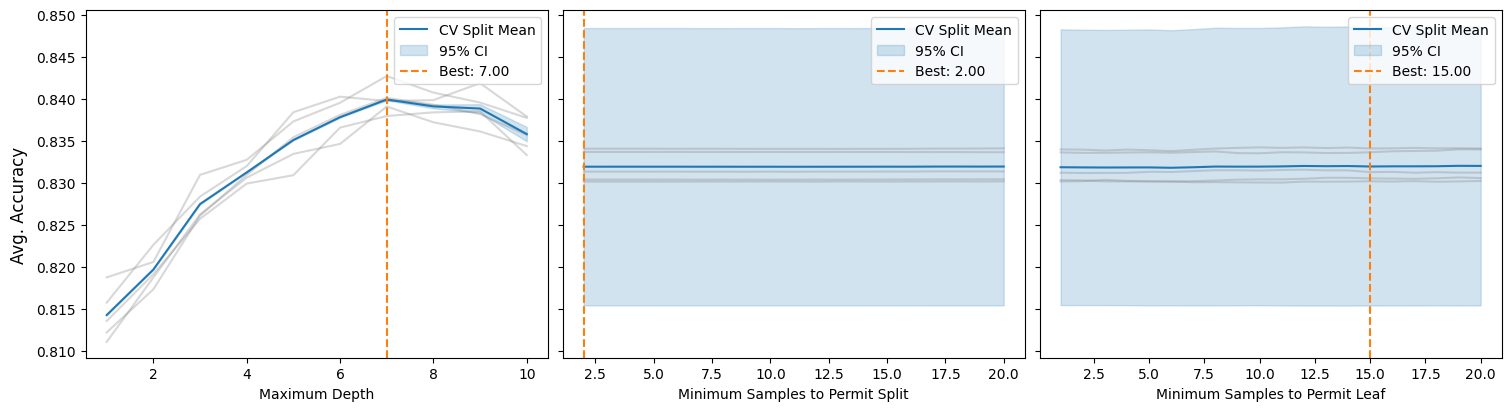

In [40]:
if optimize["Decision Tree"]:
    f, axs = plt.subplots(ncols=3, layout='constrained', sharey=True, figsize=(15, 4), dpi=dev_dpi if dev_mode else prod_dpi)

    mean_col = 'mean_test_score'

    # max_depth
    depth_ax = axs[0]
    by_depth_mean = scores.groupby('param_max_depth')[score_columns].mean()
    by_depth_95ci = scores.groupby('param_max_depth')[mean_col].std() * 1.96
    for i in by_depth_mean.columns[:-1]:
        depth_ax.plot(param_grid['max_depth'], by_depth_mean[i], color="tab:grey", alpha=0.3)
    depth_ax.plot(param_grid['max_depth'], by_depth_mean[mean_col], color="tab:blue", alpha=1, label="CV Split Mean")
    depth_ax.fill_between(param_grid['max_depth'], by_depth_mean[mean_col]-by_depth_95ci, by_depth_mean[mean_col]+by_depth_95ci,
                        color="tab:blue", alpha=0.2, label="95% CI")
    best_depth = best_tree.get_params()['max_depth']
    depth_ax.axvline(best_depth, ls='--', color='tab:orange', label=f"Best: {best_depth:.2f}")
    depth_ax.set_xlabel("Maximum Depth")

    # min_samples_split
    split_ax = axs[1]
    by_split_mean = scores.groupby('param_min_samples_split')[score_columns].mean()
    by_split_95ci = scores.groupby('param_min_samples_split')[mean_col].std() * 1.96
    for i in by_split_mean.columns[:-1]:
        split_ax.plot(param_grid['min_samples_split'], by_split_mean[i], color="tab:gray", alpha=0.3)
    split_ax.plot(param_grid['min_samples_split'], by_split_mean[mean_col], color="tab:blue", alpha=1, label="CV Split Mean")
    split_ax.fill_between(param_grid['min_samples_split'], by_split_mean[mean_col]-by_split_95ci, by_split_mean[mean_col]+by_split_95ci,
                        color="tab:blue", alpha=0.2, label="95% CI")
    best_split = best_tree.get_params()['min_samples_split']
    split_ax.axvline(best_split, ls='--', color='tab:orange', label=f"Best: {best_split:.2f}")
    split_ax.set_xlabel("Minimum Samples to Permit Split")

    # min_samples_leaf
    leaf_ax = axs[2]
    by_leaf_mean = scores.groupby('param_min_samples_leaf')[score_columns].mean()
    by_leaf_95ci = scores.groupby('param_min_samples_leaf')[mean_col].std() * 1.96
    for i in by_leaf_mean.columns[:-1]:
        leaf_ax.plot(param_grid['min_samples_leaf'], by_leaf_mean[i], color="tab:gray", alpha=0.3)
    leaf_ax.plot(param_grid['min_samples_leaf'], by_leaf_mean[mean_col], color="tab:blue", alpha=1, label="CV Split Mean")
    leaf_ax.fill_between(param_grid['min_samples_leaf'], by_leaf_mean[mean_col]-by_leaf_95ci, by_leaf_mean[mean_col]+by_leaf_95ci,
                        color="tab:blue", alpha=0.2, label="95% CI")
    best_leaf = best_tree.get_params()['min_samples_leaf']
    leaf_ax.axvline(best_leaf, ls='--', color='tab:orange', label=f"Best: {best_leaf:.2f}")
    leaf_ax.set_xlabel("Minimum Samples to Permit Leaf")

    f.supylabel("Avg. Accuracy")
    for ax in axs:
        ax.legend(loc="upper right")
    plt.show();

Best max_depth: 7
Best min_samples_split: 2
Best min_samples_leaf: 15


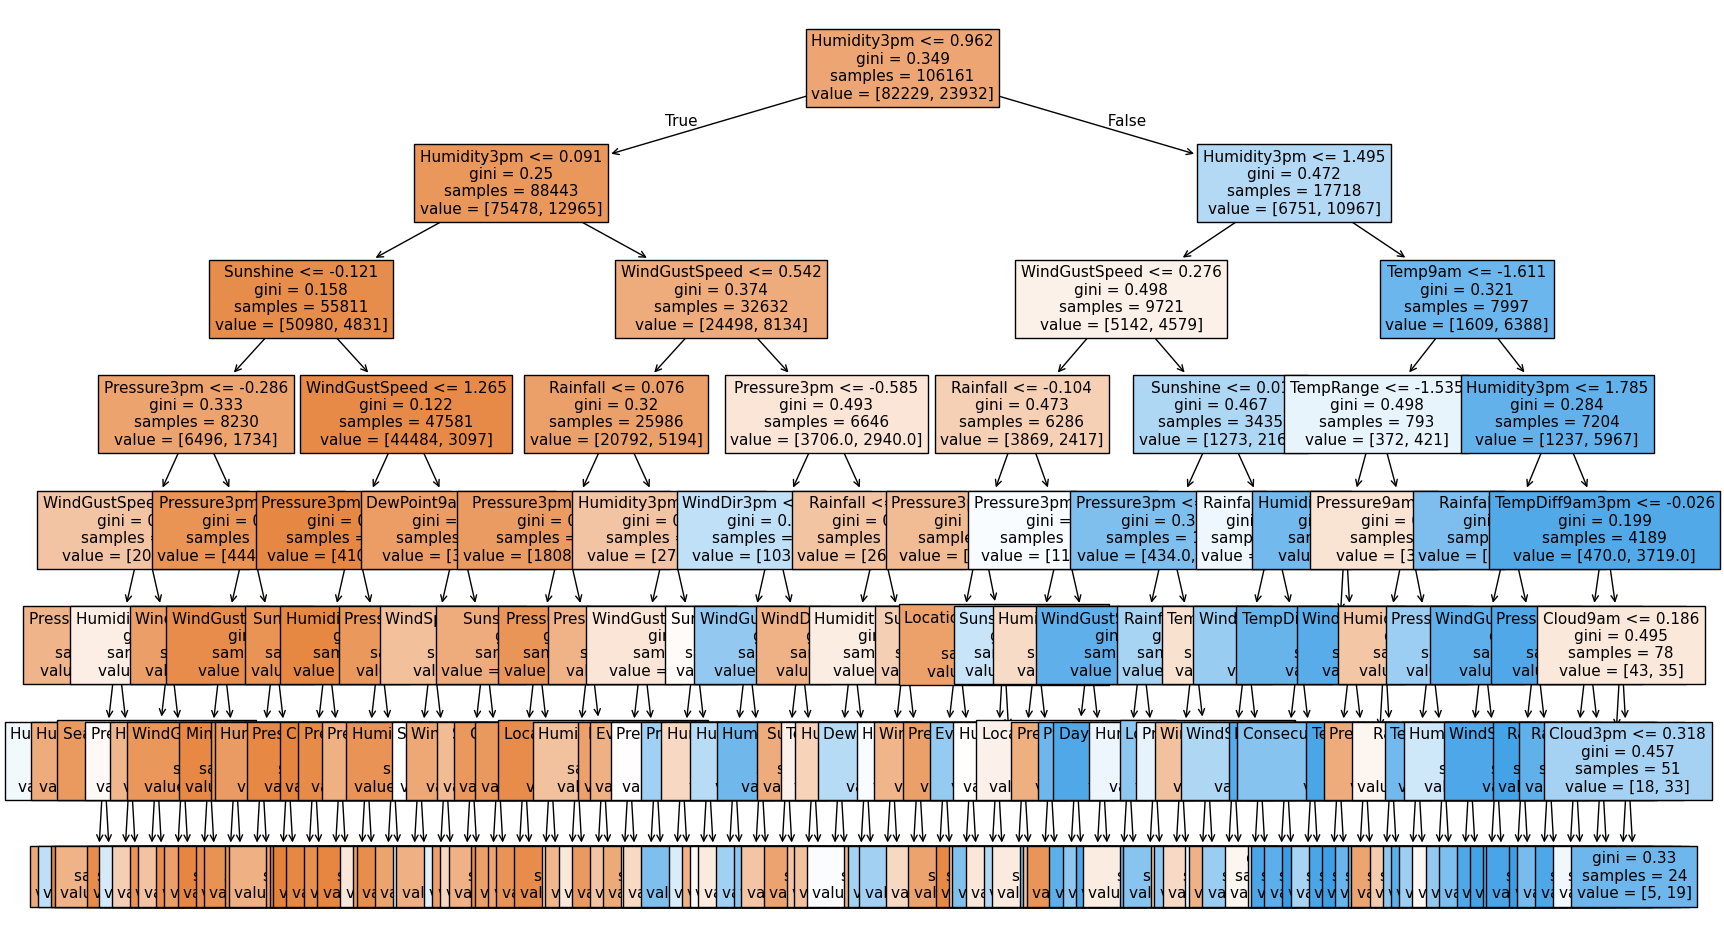

In [41]:
if optimize["Decision Tree"]:
    print("Best max_depth:", best_tree.get_params()['max_depth'])
    print("Best min_samples_split:", best_tree.get_params()['min_samples_split'])
    print("Best min_samples_leaf:", best_tree.get_params()['min_samples_leaf'])
    plot_tree(best_tree)

#### Post-Pruning
with ccp_alpha on optimal tree

In [42]:
if optimize["Decision Tree"]:
    X_ = clone(preprocessing).fit_transform(X)
    y_ = y
    X_train_, X_test_, y_train_, y_test_ = train_test_split(X_, y_, test_size=test_size, random_state=rng)

    clf = clone(best_tree)
    path = clf.cost_complexity_pruning_path(X_train_, y_train_)
    ccp_alphas, impurities = path.ccp_alphas, path.impurities

    clfs = []
    print(f"Running {len(ccp_alphas)} alphas...")
    for ccp_alpha in ccp_alphas:
        clf = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
        clf.fit(X_train_, y_train_)
        clfs.append(clf)
    print(
        "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
            clfs[-1].tree_.node_count, ccp_alphas[-1]
        )
    )

Running 118 alphas...
Number of nodes in the last tree is: 3 with ccp_alpha: 0.06205367820049795


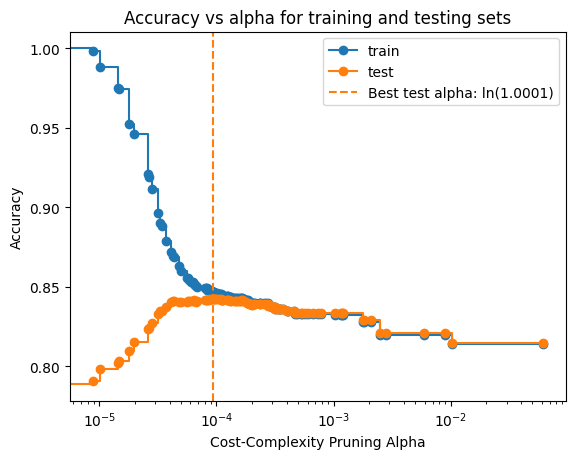

In [43]:
if optimize["Decision Tree"]:
    train_scores = np.array([clf.score(X_train_, y_train_) for clf in clfs])
    test_scores = np.array([clf.score(X_test_, y_test_) for clf in clfs])

    fig, ax = plt.subplots(dpi=dev_dpi if dev_mode else prod_dpi)

    ax.plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
    ax.plot(ccp_alphas, test_scores, marker="o", label="test", drawstyle="steps-post")

    best_alpha = ccp_alphas[test_scores.argmax()]
    ax.axvline(best_alpha, ls='--', color="tab:orange", label=f"Best test alpha: ln({np.exp(best_alpha):.5g})")

    ax.set_xscale('log')
    ax.set_xlabel("Cost-Complexity Pruning Alpha")
    ax.set_ylabel("Accuracy")
    ax.set_title("Accuracy vs alpha for training and testing sets")
    ax.legend()
    plt.show()

Best max_depth: 7
Best min_samples_split: 2
Best min_samples_leaf: 15


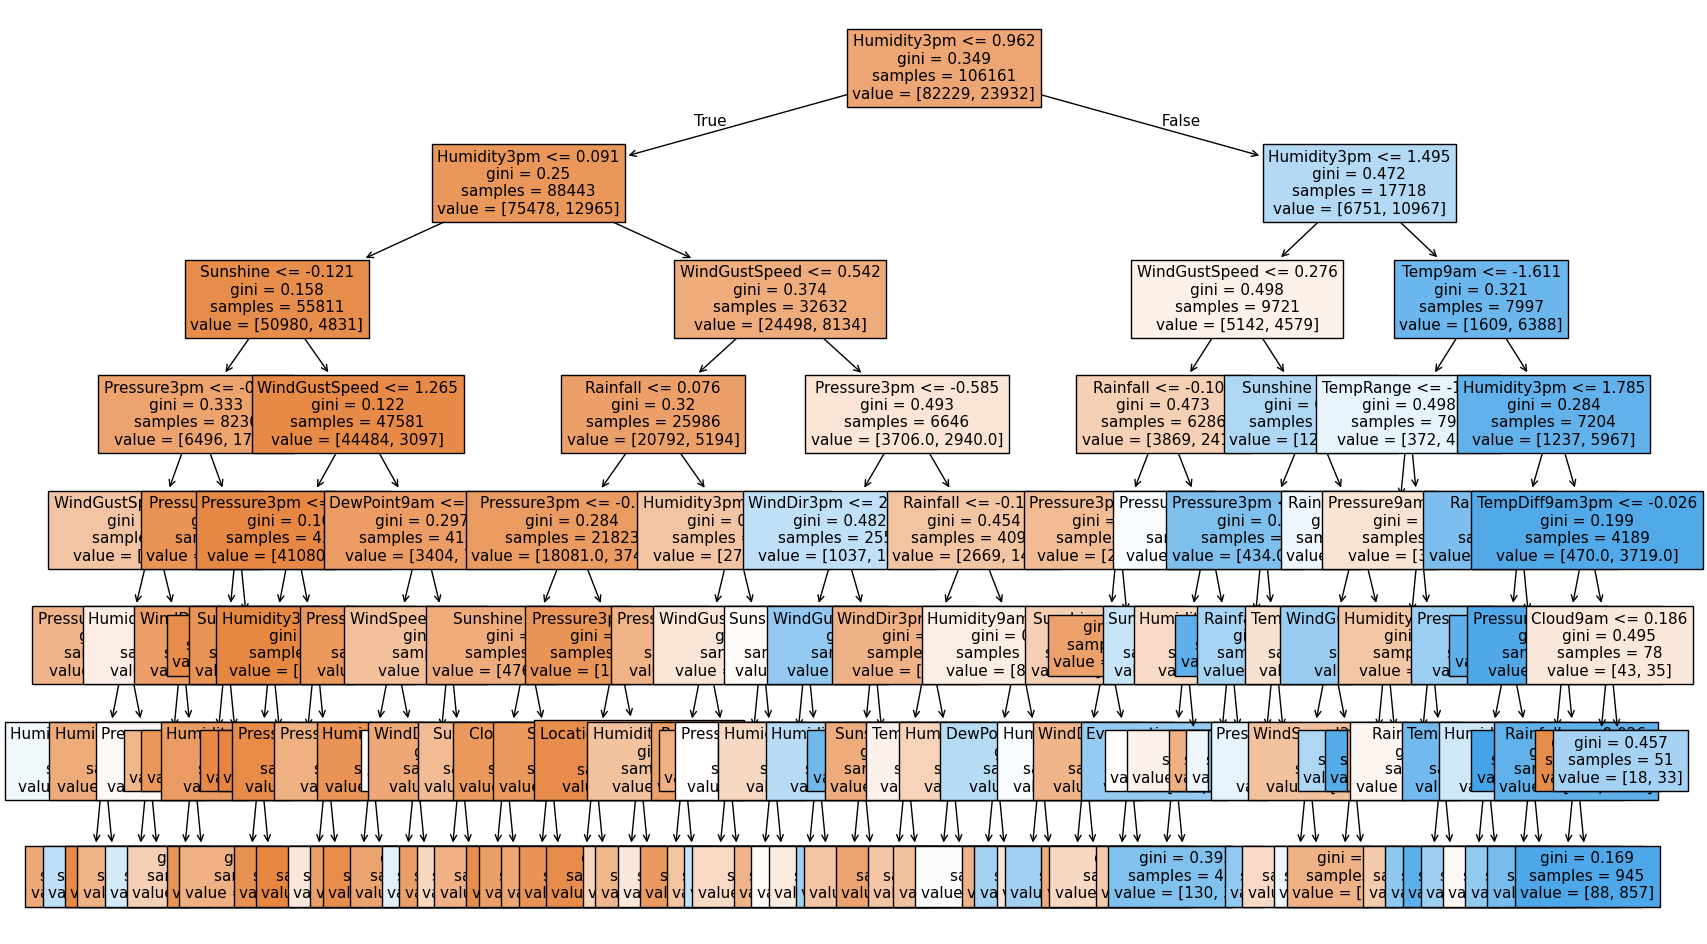

In [44]:
if optimize["Decision Tree"]:
    pruned_tree = make_pipeline(clone(preprocessing), clone(best_tree).set_params(ccp_alpha=best_alpha))
    pruned_tree.fit(X_train, y_train)
    pruned_tree_model = pruned_tree['decisiontreeclassifier']
    models["best_prunedtree"] = {"pipeline": pruned_tree, "model": pruned_tree_model, 
                                 "cost_complexity_pruning": {"model": clf, "cost_complexity_pruning_path": path}}
    print("Best max_depth:", pruned_tree_model.get_params()['max_depth'])
    print("Best min_samples_split:", pruned_tree_model.get_params()['min_samples_split'])
    print("Best min_samples_leaf:", pruned_tree_model.get_params()['min_samples_leaf'])
    plot_tree(pruned_tree_model)

### Improved Model
Random forest, boosting, other ensemble

#### Bagging

Bagging trains several base classifiers `estimator` on random subsets of the training data and aggregates their predictions by voting (for classification) or averaging (for regression). Note that the fitted outputs `estimator_` and `estimators_` are NOT the model to be used in prediction. Use the bagging model itself.

In [45]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bags = make_pipeline(
    clone(preprocessing),
    BaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=4, random_state=rng),
        n_estimators=100,
        random_state=rng
    )
)
bags.fit(X_train, y_train)
models["bagging"] = {"pipeline": bags, "model": bags['baggingclassifier']}

Run through the number of estimators to get the optimal (i.e. that which maximizes test score).

In [46]:
if optimize["Bagging"]:
    # This takes about 35min to fit
    ns = np.arange(1, 100)
    param_grid = {"n_estimators": ns}
    bagscv = make_pipeline(
        clone(preprocessing),
        GridSearchCV(
            BaggingClassifier(
                estimator=DecisionTreeClassifier(max_depth=4, random_state=rng),
                random_state=rng,
                verbose=1
            ),
            param_grid
        )
    ).fit(X_train, y_train)

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.4s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.4s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]

In [47]:
if optimize["Bagging"]:
    split_cols = ['split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score']
    mean_col = 'mean_test_score'
    std_col = 'std_test_score'
    feat_col = 'param_n_estimators'
    cols = [mean_col, std_col, feat_col]
    cols.extend(split_cols)
    bagscv_model = bagscv['gridsearchcv']
    scores_ = pd.DataFrame(bagscv_model.cv_results_)[cols]

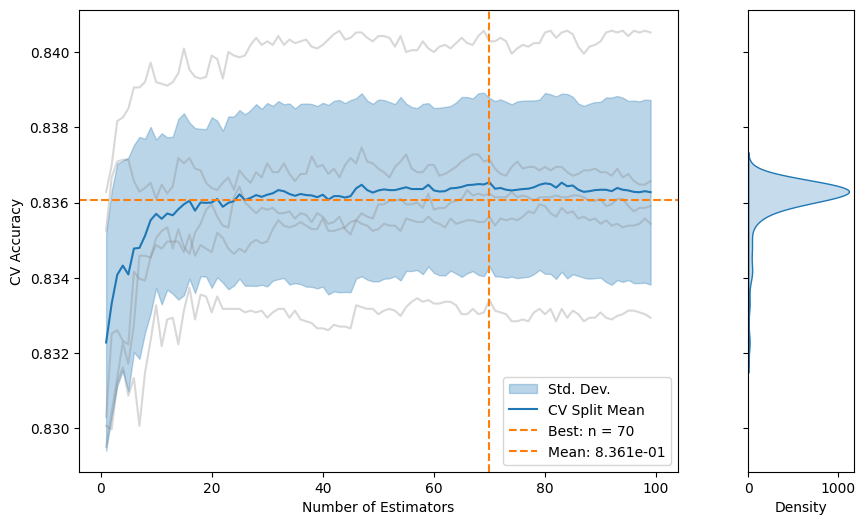

In [48]:
import seaborn as sns

if optimize["Bagging"]:
    main_ratio = .85
    f, axs = plt.subplots(ncols=2, sharey=True, figsize=(10, 6), width_ratios=(main_ratio, 1-main_ratio), dpi=dev_dpi if dev_mode else prod_dpi)

    ax = axs[0]
    ax.plot(ns, scores_[split_cols], color="tab:grey", alpha=0.3)
    ci95 = scores_[std_col]
    ax.fill_between(ns, scores_[mean_col]-ci95, scores_[mean_col]+ci95, color="tab:blue", alpha=0.3, label="Std. Dev.")
    ax.plot(ns, scores_[mean_col], label="CV Split Mean", color="tab:blue")
    # ax.set_xscale('log')

    best_n = ns[scores_[mean_col].argmax()]
    ax.axvline(best_n, ls='--', color="tab:orange", label=f"Best: n = {best_n}")
    mean_acc = np.mean(scores_[split_cols])
    ax.axhline(mean_acc, ls='--', color="tab:orange", label=f"Mean: {mean_acc:.3e}")

    dist_ax = axs[1]
    sns.kdeplot(scores_, y=mean_col, ax=dist_ax, fill=True)

    ax.set_xlabel("Number of Estimators")
    ax.set_ylabel("CV Accuracy")
    ax.legend()
    plt.plot();

The above basically just demonstrates Condorcet's Jury Theorem: more estimators are more right.

#### Random Forest

Random forest is basically the same as [bagging](#bagging) above but also randomly selects a set of features for each tree. Note that this has native support missing values: i.e. it doesn't (strictly speaking) need data cleaning (well, of missing values that is).

In [49]:
from sklearn.ensemble import RandomForestClassifier

forest = make_pipeline(
    clone(preprocessing),
    RandomForestClassifier(
        n_estimators=300,
        max_depth=4,
        max_features='sqrt',
        random_state=rng
    )
).fit(X_train, y_train)

In [50]:
models["Random Forest"] = {"pipeline": forest, "model": forest['randomforestclassifier']}

#### Boosting

In [51]:
from sklearn.ensemble import GradientBoostingClassifier

boost = make_pipeline(
    clone(preprocessing),
    GradientBoostingClassifier(
        n_estimators=120,
        max_depth=4,
        random_state=rng
    )
).fit(X_train, y_train)

In [52]:
models["Boosting"] = {"pipeline": boost, "model": boost['gradientboostingclassifier']}

## Evaluation
With confucion matrix and suitable classification matrix

## Limitations

### False Positives and Negatives

## References